In [ ]:
import os

import huggingface_hub
from omegaconf import OmegaConf

/workspace/disinfo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Paths
cfg = OmegaConf.load("../../config/default.yaml")
base_path = os.path.expanduser(cfg.data.paths.base)
kaggle_data_path = os.path.expanduser(cfg.data.paths.kaggle)
hf_data_path = os.path.expanduser(cfg.data.paths.hf)

In [ ]:
# Login to HF
HF_TOKEN = os.getenv("HF_TOKEN") 
huggingface_hub.login()
# Create dir if does not exist
os.makedirs(hf_data_path, exist_ok=True)
# Download the dataset from Hugging Face
huggingface_hub.snapshot_download(
    repo_id="neuralcatcher/hateful_memes",
    repo_type="dataset",
    local_dir=hf_data_path
)

In [ ]:
import kagglehub
kagglehub.login()
os.environ["KAGGLEHUB_CACHE"] = "./hateful_memes_kaggle"  # Set your desired path here
# Download the dataset from Kaggle
path = kagglehub.dataset_download("parthplc/facebook-hateful-meme-dataset")

In [ ]:
# Move kaggle files
!mv {kaggle_data_path}/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/* {kaggle_data_path}/
!rm -rf {kaggle_data_path}/datasets

### Compare both datasets

In [3]:
import pandas as pd

In [4]:
kaggle_images = os.listdir(f"{kaggle_data_path}/img")
hf_images = os.listdir(f"{hf_data_path}/img")

In [5]:
print("Kaggle images:", len(kaggle_images))
print("Hugging Face images:", len(hf_images))

Kaggle images: 10000
Hugging Face images: 9664


In [7]:
# Kaggle: Validate all images in labels
kaggle_labels = pd.DataFrame()
splits = ['dev', 'test', 'train']
for split in splits:
    df_tmp = pd.read_json(f'{kaggle_data_path}/{split}.jsonl', lines=True)
    df_tmp['source'] = split
    kaggle_labels = pd.concat([kaggle_labels, df_tmp])

missing_labels = kaggle_labels['label'].isna().sum() / len(kaggle_labels)
print(f'Missing labels: {missing_labels} %')
print(kaggle_labels.groupby('source')['label'].apply(lambda x: x.isna().sum()))

kaggle_images_labels = kaggle_labels['img'].str.lstrip('img/').to_list()
print(f'\nLabels for all images: {set(kaggle_images_labels) == set(kaggle_images)}')

Missing labels: 0.1 %
source
dev         0
test     1000
train       0
Name: label, dtype: int64

Labels for all images: True


In [8]:
# Hugging Face: Validate all images in labels
hf_labels = pd.DataFrame()
splits = ['dev_seen', 'dev_unseen', 'test_seen', 'test_unseen', 'train']
for split in splits:
    df_tmp = pd.read_json(f'{hf_data_path}/{split}.jsonl', lines=True)
    df_tmp['source'] = split
    hf_labels = pd.concat([hf_labels, df_tmp])

missing_labels = hf_labels['label'].isna().sum() / len(hf_labels)
print(f'Missing labels: {missing_labels} %')

Missing labels: 0.0 %


In [9]:
hf_images_labels = hf_labels['img'].str.lstrip('img/').to_list()

In [10]:
all_data = pd.merge(hf_labels, kaggle_labels, on=['id', 'img', 'text'], how='outer', suffixes=('_hf', '_kaggle'))

all_images = kaggle_images + hf_images
all_data['img_found_kaggle'] = all_data['img'].str.lstrip('img/').isin(kaggle_images)
all_data['img_found_hf'] = all_data['img'].str.lstrip('img/').isin(hf_images)
all_data['img_found_all'] = all_data['img'].str.lstrip('img/').isin(all_images)

In [13]:
all_grouped = all_data.groupby('source_hf')[['img_found_kaggle', 'img_found_hf', 'img_found_all']].agg(['sum', 'count'])

In [17]:
all_hateful = os.path.expanduser(cfg.data.paths.all_hateful)

all_data.to_csv(f"{all_hateful}/hateful_memes_all.csv", index=False)
all_grouped.to_csv(f"{all_hateful}/hateful_memes_all_grouped.csv", index=False)

## Display images

In [1]:
import os
import pandas as pd
from omegaconf import OmegaConf

from hate_meme.data_processing.annotate import *

In [2]:
cfg = OmegaConf.load("../../config/default.yaml")

all_hateful_data = os.path.expanduser(cfg.data.paths.all_hateful)
hf_data = os.path.expanduser(cfg.data.paths.hf)
kaggle_data_path = os.path.expanduser(cfg.data.paths.kaggle)

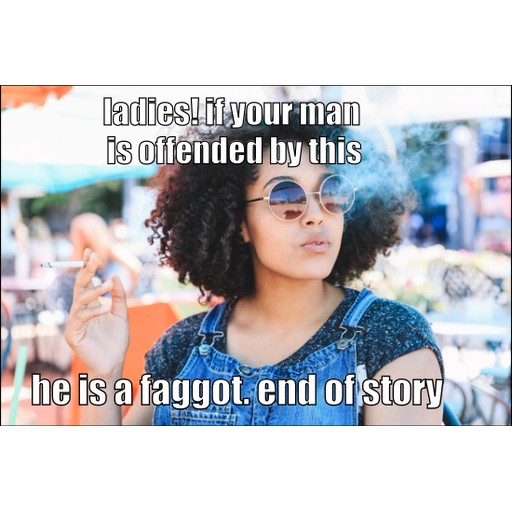

In [4]:
df = pd.read_csv(f'{all_hateful_data}/hateful_memes_all.csv')

not_in_hf_data = df[(df['img_found_kaggle'] == True) & (df['img_found_hf'] == False)]

for i in range(len(df)):
    row = not_in_hf_data.iloc[i]
    img_path = f'{kaggle_data_path}/{row['img']}' 
    clear_output(wait=True)
    try:
        display_fixed_image(img_path, size=(512, 512))
    except FileNotFoundError:
        print(f"Image not found: {img_path}")
    
    user_input = input()
    if user_input == '':
        continue
    elif user_input == 'q':
        break


## Plot

In [ ]:
from matplotlib_venn import venn2, venn3
import matplotlib.pyplot as plt

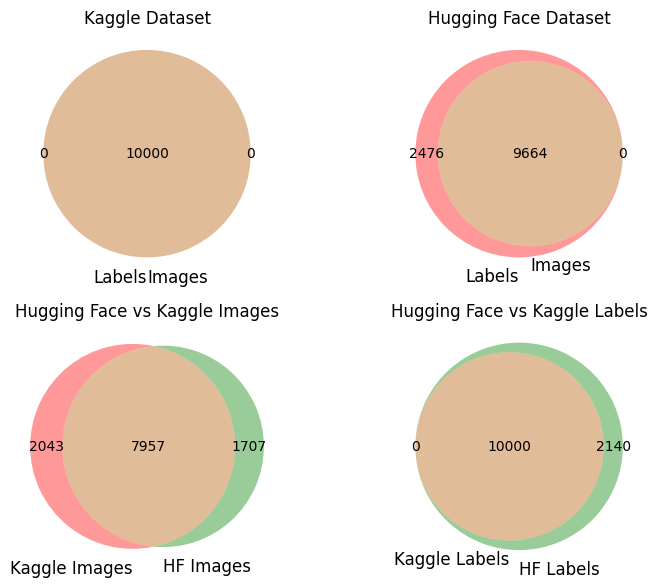

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))  # Reduced figure size

# Kaggle: Labels vs Images
plt.sca(axs[0, 0])
venn2([set(kaggle_images_labels), set(kaggle_images)], set_labels=('Labels', 'Images'))
plt.title("Kaggle Dataset")

# HF: Labels vs Images
plt.sca(axs[0, 1])
venn2([set(hf_images_labels), set(hf_images)], set_labels=('Labels', 'Images'))
plt.title("Hugging Face Dataset")

# Kaggle Images vs HF Images
plt.sca(axs[1, 0])
venn2([set(kaggle_images), set(hf_images)], set_labels=('Kaggle Images', 'HF Images'))
plt.title("Hugging Face vs Kaggle Images")

# Kaggle Labels vs HF Labels
plt.sca(axs[1, 1])
venn2([set(kaggle_images_labels), set(hf_images_labels)], set_labels=('Kaggle Labels', 'HF Labels'))
plt.title("Hugging Face vs Kaggle Labels")

plt.tight_layout()
plt.show()

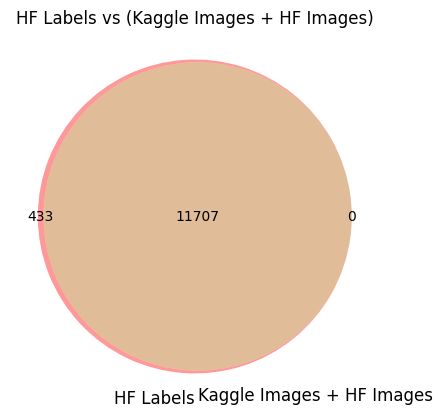

In [ ]:
venn2([set(hf_images_labels), set(kaggle_images).union(set(hf_images))], set_labels=('HF Labels', 'Kaggle Images + HF Images'))
plt.title("HF Labels vs (Kaggle Images + HF Images)")
plt.show()

# Notes on dataset

## Intro
There are two versions of the hateful meme dataset which where used for two challenges:
- Facebook Challenge: [Kiela 2020](https://arxiv.org/abs/2005.04790)
- NeurIPS Challenge: [Kiela 2021](https://proceedings.mlr.press/v133/kiela21a.html)

Both papers use the same hatefulness definition:
> A direct or indirect attack on people based on characteristics, including ethnicity, race, nationality, immigration status, religion, caste, sex, gender identity, sexual orientation, and disability or disease. We define attack as violent or dehumanizing (comparing people to non-human things, e.g. animals) speech, statements of inferiority, and calls for exclusion or segregation. Mocking hate crime is also considered hate speech.

The Facebook challenge also mentions that, although some works argue for a three-way distinction between, for example, hateful, offensive, and normal, they opt to use only two categories in order to make classification more actionable.

## Dataset Construction
The datasets were created in a 4 step-process:
1. Filtering: One million images were retrieved from the internet and then filtered to discard non-meme images, duplicates and violating memes (nudity, violence, etc.).
2. Meme construction: Original memes where "reconstructed" with a new stock image and text.
3. Hatefulness rating: Annotation of hate vs. not hate
4. Benign confounders: A benign confounder is a minimum replacement image or replacement text that flips the label for a given multimodal meme from hateful to non-hateful. Adding benign confounders makes the dataset more robust against biases.

## Data Description
### Facebook Challenge
The dataset contains 10k images and is split into:
| Split | Percentage |
|-------|------------|
| Train | 65%        |
| Dev   | 5%         |
| Test  | 10%        |

The dataset's content is distributed as follows:

| Category                   | Percentage |
|---------------------------|------------|
| Multimodal hate           | 40%        |
| Unimodal hate             | 10%        |
| Benign text confounder    | 20%        |
| Benign image confounder   | 20%        |
| Random non-hateful        | 10%        |

### NeurIPS Challenge
For the NeurIPS challenge, the entire dataset was reannotated. The new dataset is distributed as follows:

| Split        | Total | Not-hate | Hate | MM Hate | UM Hate | Img Conf | Txt Conf | Rand Benign |
|--------------|-------|----------|------|---------|---------|----------|----------|--------------|
| Train        | 8500  | 5481     | 3019 | 1100    | 1919    | 1530     | 1530     | 2421         |
| Dev seen     | 500   | 253      | 247  | 200     | 47      | 100      | 100      | 53           |
| Dev unseen   | 540   | 340      | 200  | 200     | 0       | 170      | 170      | 0            |
| Test seen    | 1000  | 510      | 490  | 380     | 110     | 190      | 190      | 130          |
| Test unseen  | 2000  | 1250     | 750  | 750     | 0       | 625      | 625      | 0            |

## Data found
| source_hf   | Kaggle Images Found  | HF Images Found  | All Images Found  | Nr. Images (In labels) |
|-------------|----------------------|------------------|-------------------|---------------------|
| dev_seen    | 500                  | 398              | 500               | 500                 |
| dev_unseen  | 400                  | 433              | 514               | 540                 |
| test_seen   | 1000                 | 815              | 1000              | 1000                |
| test_unseen | 0                    | 1593             | 1593              | 2000                |
| train       | 8500                 | 6744             | 8500              | 8500                |
